# Project #3: Visualizations for the Federal Highway Administration (FHWA)
**Author:** Blake Green

**Date:** 3/31/2026<YYYY-MM-DD>  
**Client:** Federal Highway Administration (FHWA)


In [2]:
#In this code cell we import all necessary packages that might need to be used for the coding of this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#In this code cell we need to load the datasets that will be used
nhts_data = pd.read_csv('NHTS(in).csv')
ngsim_data = pd.read_csv('NGSIM(in).csv')

#nhts_data.columns - this line and the next line are to help look at the column names for the future
#ngsim_data.columns

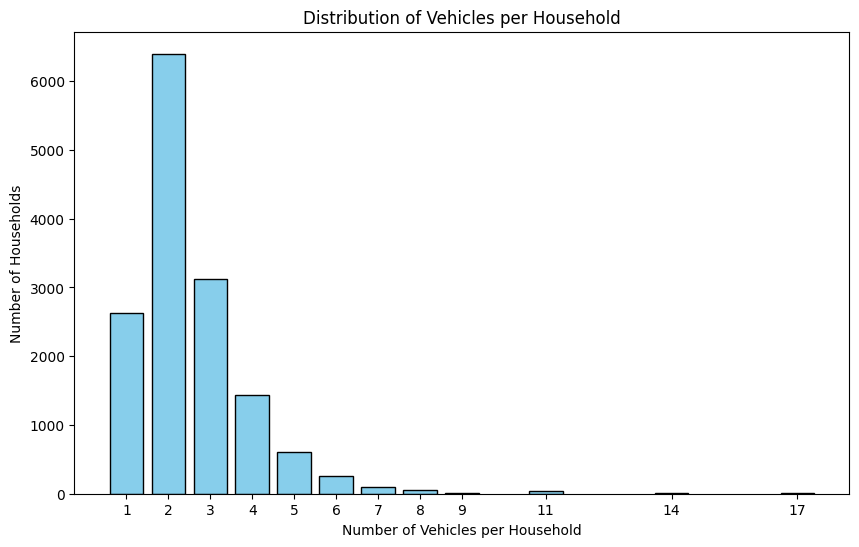

In [19]:
#This section will remove missing values from the NHTS dataset

nhts_clean = nhts_data.dropna(subset = ['vehicles_per_household','household_size','vehicle_age','vehicle_type']) #filters out NA values
vehicle_counts = nhts_clean['vehicles_per_household'].value_counts().sort_index() #this counts how many households have each number of vehicles

#With the cleaned dataset and counts we can create the bar chart

plt.figure(figsize = (10,6))
plt.bar(vehicle_counts.index, vehicle_counts.values, color = 'skyblue', edgecolor = 'black')
plt.xlabel('Number of Vehicles per Household')
plt.ylabel('Number of Households')
plt.title('Distribution of Vehicles per Household')
plt.xticks(vehicle_counts.index)
plt.show()

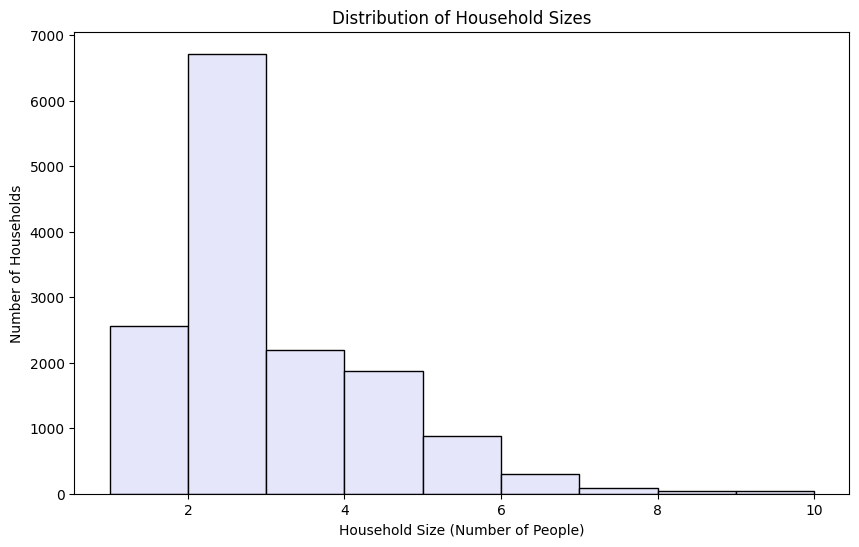

In [7]:
#This block will create the histogram of household size

plt.figure(figsize = (10,6))
plt.hist(nhts_clean['household_size'], bins = 9, color = 'lavender', edgecolor = 'black')
plt.xlabel('Household Size (Number of People)')
plt.ylabel('Number of Households')
plt.title('Distribution of Household Sizes')
plt.show()

<Figure size 1000x1000 with 0 Axes>

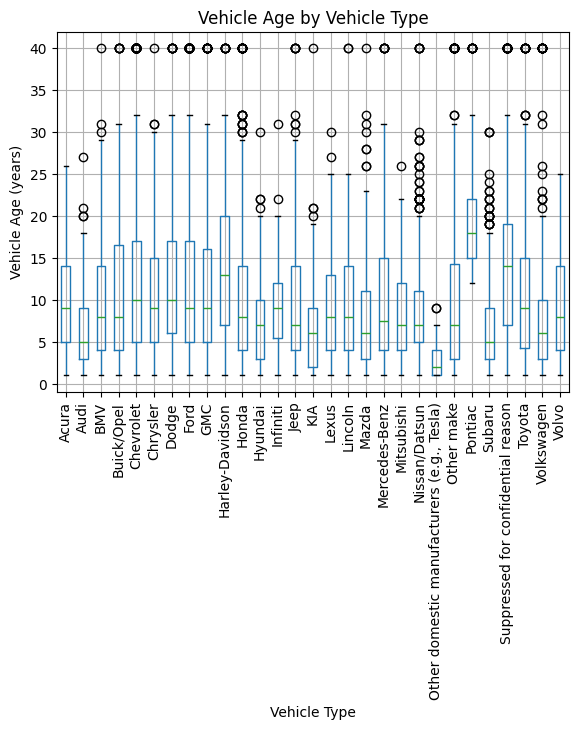

In [8]:
##### This block creates the boxplots of vehicle makes by year


plt.figure(figsize = (10,10))
boxplot = nhts_data.boxplot(column = 'vehicle_age', by = 'make',)
plt.xlabel('Vehicle Type')
plt.ylabel('Vehicle Age (years)')
plt.suptitle('')
plt.title('Vehicle Age by Vehicle Type')
plt.xticks(rotation = 90)
plt.tight_layout
plt.show()

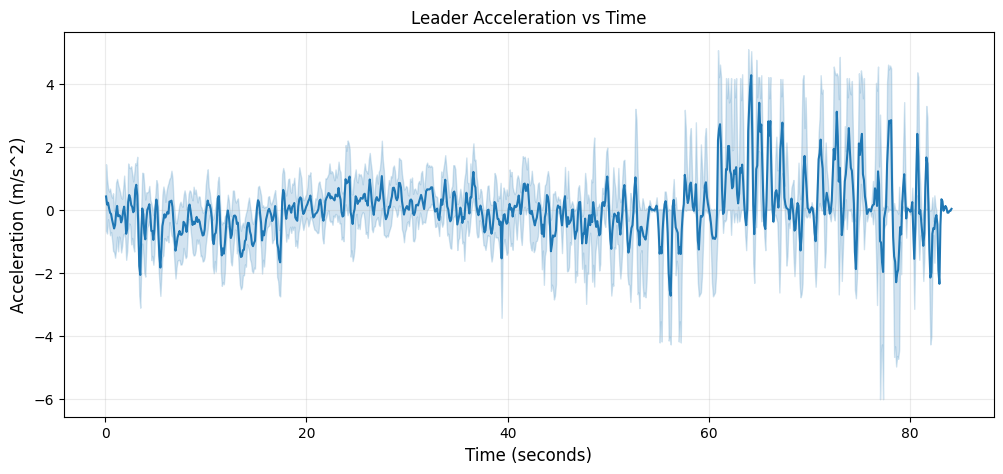

In [10]:
#This block will create the time series plot that analyzes the leader acceleration vs time


# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize = (12,5))
# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_acc(m/s^2)'])
# Step 3: add customizations
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Acceleration (m/s^2)', fontsize = 12)
plt.title('Leader Acceleration vs Time', fontsize = 12)
plt.grid(alpha = .25)
plt.show()

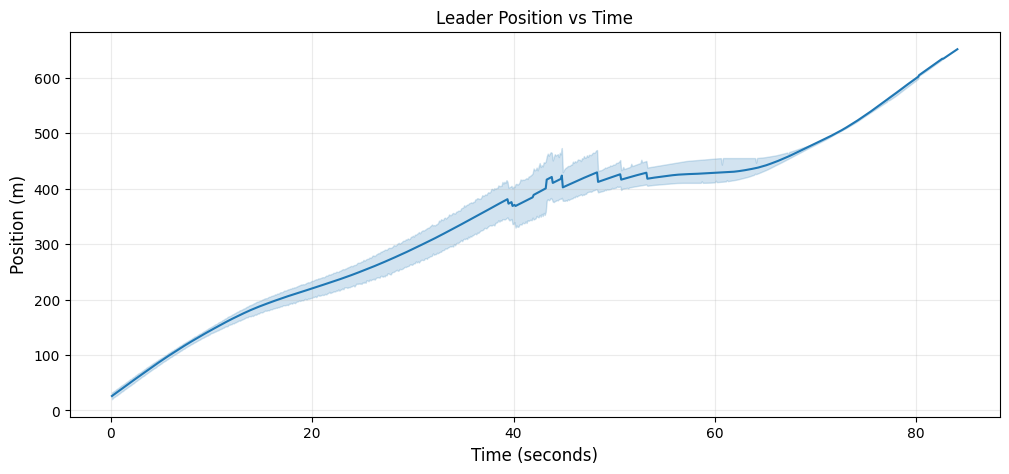

In [13]:
### Plotting Position vs Time for the leader
plt.figure(figsize = (12,5))
# replicate the above steps, but now visualize the leader_position(m) data with time 
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['leader_position(m)'])
plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Position (m)', fontsize = 12)
plt.title('Leader Position vs Time', fontsize = 12)
plt.grid(alpha = .25)
plt.show()


In [14]:
#Now the IDM Simulation needs to be created
#The first step is to define the function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Calculate the desired minimum gap s_star
    
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    
    return acceleration

In [15]:
# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Select a trajectory pair

trajectory_number = 2
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop = True)

# Extract the leader's position and speed over time

time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data
dt = 0.1 #seconds

In [16]:
# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start

# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]         #this makes the starting value [0] same as the follower vehicle speed

In [17]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a, b, delta)

    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i]* dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i]* dt

print("Simulation complete!")

Simulation complete!


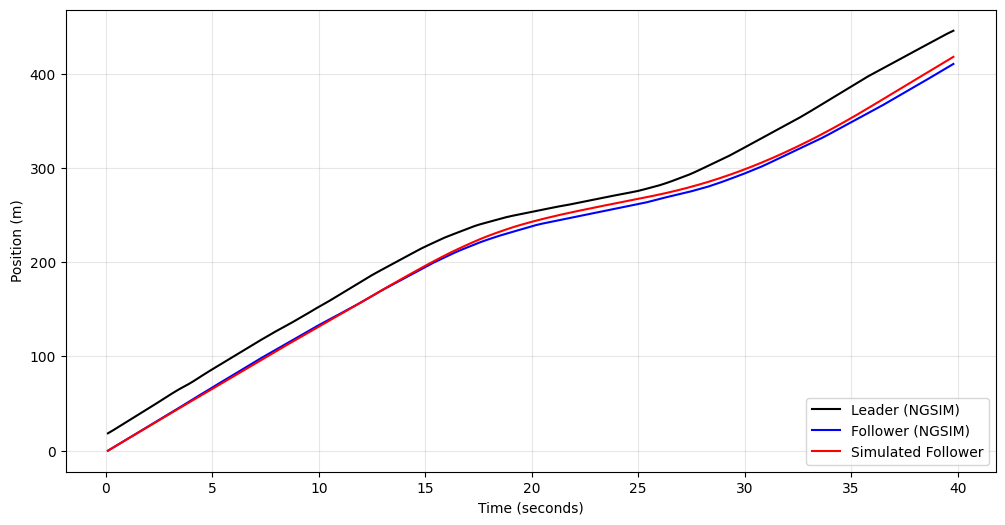

In [20]:
#Now the simulation can be plotted
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower
plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, label = 'Leader (NGSIM)', color = 'black')
plt.plot(time_data, data_subset['follower_position(m)'].values, label = 'Follower (NGSIM)', color = 'blue')
plt.plot(time_data, sim_position, label = 'Simulated Follower', color = 'red')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend(loc = 'lower right')
plt.grid(True, alpha = .3)
plt.show()